In [1]:
# Cell 1: Mount Drive, copy JSON, and load data
import os
import json
import shutil
from pathlib import Path
from google.colab import drive

os.environ["CUDA_VISIBLE_DEVICES"] = ""

drive.mount("/content/drive")

drive_path = Path("/content/drive/MyDrive/final_project/hotpotqa_dev_2017wiki_1000_converted.json")

local_dir = Path("/content/disk")
local_dir.mkdir(parents=True, exist_ok=True)

local_path = local_dir / drive_path.name
shutil.copy2(drive_path, local_path)

with open(local_path, "r", encoding="utf-8") as f:
    data = json.load(f)

if isinstance(data, dict):
    for key in ["data", "examples", "items"]:
        if key in data and isinstance(data[key], list):
            data = data[key]
            break

print("Loaded file:", local_path)
print("Number of examples:", len(data))
print("First example keys:", list(data[0].keys()))

Mounted at /content/drive
Loaded file: /content/disk/hotpotqa_dev_2017wiki_1000_converted.json
Number of examples: 1000
First example keys: ['question', 'answer', 'type', 'titles', 'docs_chunks', 'docs', 'title_chunks', 'supports']


In [2]:
# Cell 2: Convert all docs into paragraphs
import pandas as pd

def split_paragraphs(text):
    return [p.strip() for p in str(text).split("\n") if p.strip()]

paragraph_rows = []

for ex_idx, ex in enumerate(data):
    question = ex.get("question")
    answer = ex.get("answer")
    q_type = ex.get("type")
    titles = ex.get("titles", [])
    docs = ex.get("docs", [])

    for doc_idx, doc in enumerate(docs):
        title = titles[doc_idx] if doc_idx < len(titles) else None
        paragraphs = split_paragraphs(doc)

        for para_idx, para in enumerate(paragraphs):
            paragraph_rows.append({
                "ex_idx": ex_idx,
                "doc_idx": doc_idx,
                "paragraph_idx": para_idx,
                "question": question,
                "answer": answer,
                "type": q_type,
                "title": title,
                "paragraph": para,
                "char_count": len(para),
                "word_count": len(para.split())
            })

paragraphs_df = pd.DataFrame(paragraph_rows)

print("Total questions:", len(data))
print("Total docs:", sum(len(ex.get("docs", [])) for ex in data))
print("Total paragraphs:", len(paragraphs_df))

paragraphs_df.head(10)

Total questions: 1000
Total docs: 10000
Total paragraphs: 129185


,ex_idx,doc_idx,paragraph_idx,question,answer,type,title,paragraph,char_count,word_count
0,0,0,0,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,"Meet Corliss Archer, a program from radio's Go...",412,76
1,0,0,1,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,Priscilla Lyon and Janet Waldo successively po...,204,31
2,0,0,2,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,"Perpetually perky, breathless and well-intenti...",410,58
3,0,0,3,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,"Harry Archer, Corliss's father, is a lawyer wh...",405,68
4,0,0,4,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,Other frequent characters include Mildred Ames...,244,34
5,0,0,5,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,"""Meet Corliss Archer"" was written by F. Hugh H...",334,59
6,0,0,6,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,"Like many other radio shows, ""Meet Corliss Arc...",577,93
7,0,0,7,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,Robin Morgan portrayed Corliss in a live telec...,139,24
8,0,0,8,What government position was held by the woman...,Chief of Protocol,bridge,Meet Corliss Archer,Radio listeners had to use their imaginations ...,680,114
9,0,1,0,What government position was held by the woman...,Chief of Protocol,bridge,Shirley Temple,"Shirley Temple Black (April 23, 1928 – Februar...",353,59


In [3]:
# Cell 3: Count tokens for each paragraph
!pip -q install tiktoken

import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

paragraphs_df["token_count"] = paragraphs_df["paragraph"].apply(
    lambda x: len(encoding.encode(str(x)))
)

print("Token counting is done.")
paragraphs_df[["ex_idx", "doc_idx", "paragraph_idx", "title", "token_count", "word_count", "char_count"]].head(10)

Token counting is done.


,ex_idx,doc_idx,paragraph_idx,title,token_count,word_count,char_count
0,0,0,0,Meet Corliss Archer,113,76,412
1,0,0,1,Meet Corliss Archer,49,31,204
2,0,0,2,Meet Corliss Archer,100,58,410
3,0,0,3,Meet Corliss Archer,93,68,405
4,0,0,4,Meet Corliss Archer,56,34,244
5,0,0,5,Meet Corliss Archer,89,59,334
6,0,0,6,Meet Corliss Archer,123,93,577
7,0,0,7,Meet Corliss Archer,42,24,139
8,0,0,8,Meet Corliss Archer,152,114,680
9,0,1,0,Shirley Temple,88,59,353


In [4]:
# Cell 4: Show token statistics report
token_stats = paragraphs_df["token_count"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

print("Token statistics:")
print(token_stats)

print("\nExtra report:")
print("Min tokens:", paragraphs_df["token_count"].min())
print("Max tokens:", paragraphs_df["token_count"].max())
print("Mean tokens:", round(paragraphs_df["token_count"].mean(), 2))
print("Median tokens:", round(paragraphs_df["token_count"].median(), 2))
print("Total tokens:", int(paragraphs_df["token_count"].sum()))
print("Total paragraphs:", len(paragraphs_df))

print("\nTop 10 longest paragraphs:")
paragraphs_df.sort_values("token_count", ascending=False)[
    ["ex_idx", "doc_idx", "paragraph_idx", "title", "token_count", "paragraph"]
].head(10)

Token statistics:
count    129185.000000
mean        105.036568
std          80.009137
min           1.000000
25%          47.000000
50%          90.000000
75%         144.000000
90%         207.000000
95%         253.000000
99%         366.000000
max        1895.000000
Name: token_count, dtype: float64

Extra report:
Min tokens: 1
Max tokens: 1895
Mean tokens: 105.04
Median tokens: 90.0
Total tokens: 13569149
Total paragraphs: 129185

Top 10 longest paragraphs:


,ex_idx,doc_idx,paragraph_idx,title,token_count,paragraph
30577,205,3,0,Nashville Terminal Subdivision,1895,The Nashville Terminal Subdivision is a railro...
34095,233,9,20,Ryan Hunter-Reay,1555,In 2014 Hunter-Reay returned with Andretti Aut...
94231,703,8,0,Loan modification in the United States,1494,Loan modification is the systematic alteration...
685,5,3,0,Loan modification in the United States,1494,Loan modification is the systematic alteration...
104529,788,5,12,Disco polo,1465,In years 2002-2007 some teams continued their ...
73017,545,2,0,Varugad,1344,The hill rises about 250 feet above the level ...
68891,508,6,0,Varugad,1344,The hill rises about 250 feet above the level ...
34092,233,9,17,Ryan Hunter-Reay,1272,In 2011 Hunter-Reay returned with Andretti Aut...
119602,919,4,0,WSYY-FM,1138,WSYY-FM (94.9 FM) is a radio station broadcast...
80350,596,2,12,Despicable Me Minion Mayhem,1094,"Once the ride begins, riders see Gru's daughte..."


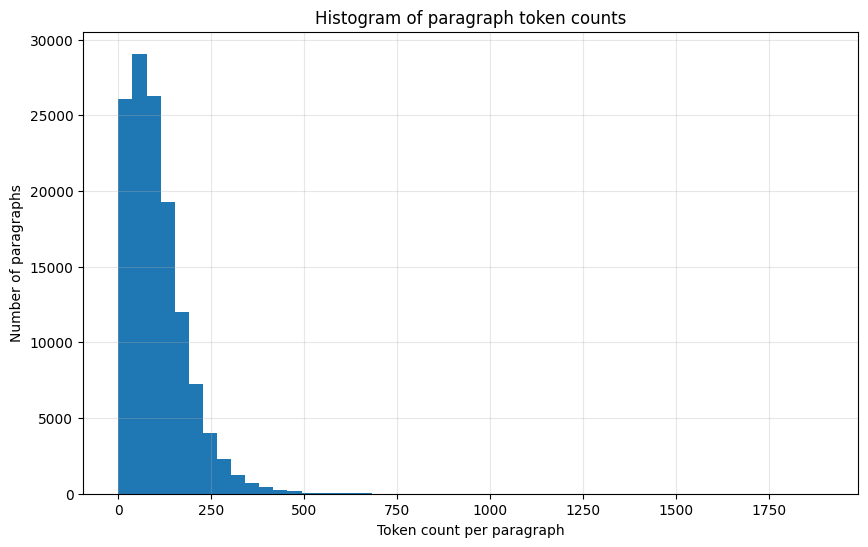

In [5]:
# Cell 5: Plot histogram of token counts
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(paragraphs_df["token_count"], bins=50)

plt.xlabel("Token count per paragraph")
plt.ylabel("Number of paragraphs")
plt.title("Histogram of paragraph token counts")
plt.grid(True, alpha=0.3)

plt.show()

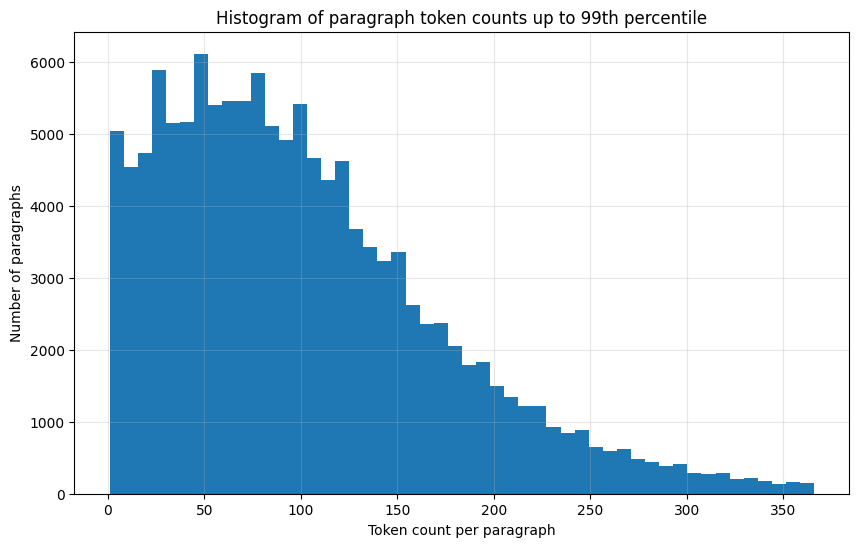

99th percentile token limit: 366
Paragraphs used in filtered histogram: 127905


In [6]:
# Cell 6: Plot histogram without extreme outliers
upper_limit = paragraphs_df["token_count"].quantile(0.99)

filtered_df = paragraphs_df[paragraphs_df["token_count"] <= upper_limit]

plt.figure(figsize=(10, 6))
plt.hist(filtered_df["token_count"], bins=50)

plt.xlabel("Token count per paragraph")
plt.ylabel("Number of paragraphs")
plt.title("Histogram of paragraph token counts up to 99th percentile")
plt.grid(True, alpha=0.3)

plt.show()

print("99th percentile token limit:", int(upper_limit))
print("Paragraphs used in filtered histogram:", len(filtered_df))

In [7]:
# Cell 7: Copy and load 2WikiMultihopQA JSON
dataset2_name = "2wikimultihopqa_dev_2020wiki_1000_converted.json"

drive_path_2wiki = Path("/content/drive/MyDrive/final_project") / dataset2_name
local_path_2wiki = local_dir / dataset2_name

shutil.copy2(drive_path_2wiki, local_path_2wiki)

with open(local_path_2wiki, "r", encoding="utf-8") as f:
    data_2wiki = json.load(f)

if isinstance(data_2wiki, dict):
    for key in ["data", "examples", "items"]:
        if key in data_2wiki and isinstance(data_2wiki[key], list):
            data_2wiki = data_2wiki[key]
            break

print("Loaded file:", local_path_2wiki)
print("Number of examples:", len(data_2wiki))
print("First example keys:", list(data_2wiki[0].keys()))

Loaded file: /content/disk/2wikimultihopqa_dev_2020wiki_1000_converted.json
Number of examples: 1000
First example keys: ['question', 'answer', 'type', 'titles', 'docs_chunks', 'docs', 'title_chunks', 'supports']


In [8]:
# Cell 8: Inspect docs formatting in one 2Wiki example
ex_idx = 0
doc_idx = 0

ex = data_2wiki[ex_idx]
doc = ex["docs"][doc_idx]
title = ex["titles"][doc_idx] if "titles" in ex and doc_idx < len(ex["titles"]) else None

print("Example index:", ex_idx)
print("Doc index:", doc_idx)
print("Title:", title)
print("Characters:", len(doc))
print("Newline count:", doc.count("\n"))
print("Double newline count:", doc.count("\n\n"))

print("\nRaw preview:")
print(repr(doc[:1500]))

print("\nParagraphs:")
for i, p in enumerate(split_paragraphs(doc)):
    print("=" * 80)
    print("Paragraph:", i)
    print(p[:700])

Example index: 0
Doc index: 0
Title: Calloway County High School
Characters: 609
Newline count: 3
Double newline count: 0

Raw preview:
'Calloway County High School is a public high school located in Murray, Kentucky. The school was formed from the consolidation of six high schools from across the county: Hazel High School, Lynn Grove High School, Kirksey High School, Almo High School, New Concord High School, and Faxon High School.\nOrganizations: Clubs/Organizations\nState champions: Wrestling: David Woods 195 lbs (2017) Bass Fishing: Bracken Robertson & Dillon Starks (2013) Boys Cross Country: 1984 (2A) Fast Pitch Softball: 2004 Girls Golf: 2012 (Individual, Anna Hack)\nW. Earl Brown, actor: Pookie Jones, 1989 KHSAA Mr. Football winner*'

Paragraphs:
Paragraph: 0
Calloway County High School is a public high school located in Murray, Kentucky. The school was formed from the consolidation of six high schools from across the county: Hazel High School, Lynn Grove High School, Kirksey Hi

In [9]:
# Cell 9: Convert all 2Wiki docs into paragraphs
paragraph_rows_2wiki = []

for ex_idx, ex in enumerate(data_2wiki):
    question = ex.get("question")
    answer = ex.get("answer")
    q_type = ex.get("type")
    titles = ex.get("titles", [])
    docs = ex.get("docs", [])

    for doc_idx, doc in enumerate(docs):
        title = titles[doc_idx] if doc_idx < len(titles) else None
        paragraphs = split_paragraphs(doc)

        for para_idx, para in enumerate(paragraphs):
            paragraph_rows_2wiki.append({
                "ex_idx": ex_idx,
                "doc_idx": doc_idx,
                "paragraph_idx": para_idx,
                "question": question,
                "answer": answer,
                "type": q_type,
                "title": title,
                "paragraph": para,
                "char_count": len(para),
                "word_count": len(para.split())
            })

paragraphs_2wiki_df = pd.DataFrame(paragraph_rows_2wiki)

print("Total questions:", len(data_2wiki))
print("Total docs:", sum(len(ex.get("docs", [])) for ex in data_2wiki))
print("Total paragraphs:", len(paragraphs_2wiki_df))

paragraphs_2wiki_df.head(10)

Total questions: 1000
Total docs: 10000
Total paragraphs: 73878


,ex_idx,doc_idx,paragraph_idx,question,answer,type,title,paragraph,char_count,word_count
0,0,0,0,Are North Marion High School (Oregon) and Seou...,no,comparison,Calloway County High School,Calloway County High School is a public high s...,299,49
1,0,0,1,Are North Marion High School (Oregon) and Seou...,no,comparison,Calloway County High School,Organizations: Clubs/Organizations,34,2
2,0,0,2,Are North Marion High School (Oregon) and Seou...,no,comparison,Calloway County High School,State champions: Wrestling: David Woods 195 lb...,206,31
3,0,0,3,Are North Marion High School (Oregon) and Seou...,no,comparison,Calloway County High School,"W. Earl Brown, actor: Pookie Jones, 1989 KHSAA...",67,11
4,0,1,0,Are North Marion High School (Oregon) and Seou...,no,comparison,Marion High School (Kansas),Marion High School is a public high school in ...,166,32
5,0,1,1,Are North Marion High School (Oregon) and Seou...,no,comparison,Marion High School (Kansas),Academics: The high school is a member of T.E....,215,35
6,0,1,2,Are North Marion High School (Oregon) and Seou...,no,comparison,Marion High School (Kansas),Sports: The Marion High School mascot is a War...,697,113
7,0,1,3,Are North Marion High School (Oregon) and Seou...,no,comparison,Marion High School (Kansas),"Notable people: Randolph Carpenter, U.S. Repre...",183,27
8,0,1,4,Are North Marion High School (Oregon) and Seou...,no,comparison,Marion High School (Kansas),Further reading: The Early Schools Of Marion C...,409,64
9,0,2,0,Are North Marion High School (Oregon) and Seou...,no,comparison,North Marion High School (West Virginia),North Marion High School is a public Double A ...,143,26


In [10]:
# Cell 10: Analyze paragraph structure
docs_structure_2wiki = []

for ex_idx, ex in enumerate(data_2wiki):
    titles = ex.get("titles", [])
    docs = ex.get("docs", [])

    for doc_idx, doc in enumerate(docs):
        paragraphs = split_paragraphs(doc)
        title = titles[doc_idx] if doc_idx < len(titles) else None

        docs_structure_2wiki.append({
            "ex_idx": ex_idx,
            "doc_idx": doc_idx,
            "title": title,
            "char_count": len(str(doc)),
            "newline_count": str(doc).count("\n"),
            "paragraph_count": len(paragraphs),
            "avg_words_per_paragraph": sum(len(p.split()) for p in paragraphs) / len(paragraphs) if paragraphs else 0
        })

docs_structure_2wiki_df = pd.DataFrame(docs_structure_2wiki)

print("Docs structure report:")
print(docs_structure_2wiki_df["paragraph_count"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
))

print("\nTop docs by paragraph count:")
docs_structure_2wiki_df.sort_values("paragraph_count", ascending=False).head(10)

Docs structure report:
count    10000.000000
mean         7.387800
std          9.248847
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
90%         15.000000
95%         23.000000
99%         44.010000
max        147.000000
Name: paragraph_count, dtype: float64

Top docs by paragraph count:


,ex_idx,doc_idx,title,char_count,newline_count,paragraph_count,avg_words_per_paragraph
3217,321,7,Robert E. Lee,88024,146,147,97.884354
7869,786,9,Lambert Hillyer,5570,144,145,5.951724
8169,816,9,John Ford,84848,142,143,98.300699
4740,474,0,Franklin D. Roosevelt,98686,135,136,112.566176
8344,834,4,Josiane Balasko,12167,128,129,15.224806
3668,366,8,Marie Antoinette,68539,118,119,94.260504
4330,433,0,Marie Antoinette,68539,118,119,94.260504
6444,644,4,William H. Seward,81753,105,106,124.018868
2476,247,6,It (2017 film),96962,99,100,161.370000
8473,847,3,Emory Johnson,40627,96,97,58.072165


In [11]:
# Cell 11: Count tokens for each 2Wiki paragraph
try:
    encoding
except NameError:
    import tiktoken
    encoding = tiktoken.get_encoding("cl100k_base")

paragraphs_2wiki_df["token_count"] = paragraphs_2wiki_df["paragraph"].apply(
    lambda x: len(encoding.encode(str(x)))
)

print("Token counting is done.")

paragraphs_2wiki_df[
    ["ex_idx", "doc_idx", "paragraph_idx", "title", "token_count", "word_count", "char_count"]
].head(10)

Token counting is done.


,ex_idx,doc_idx,paragraph_idx,title,token_count,word_count,char_count
0,0,0,0,Calloway County High School,63,49,299
1,0,0,1,Calloway County High School,7,2,34
2,0,0,2,Calloway County High School,60,31,206
3,0,0,3,Calloway County High School,22,11,67
4,0,1,0,Marion High School (Kansas),39,32,166
5,0,1,1,Marion High School (Kansas),52,35,215
6,0,1,2,Marion High School (Kansas),149,113,697
7,0,1,3,Marion High School (Kansas),40,27,183
8,0,1,4,Marion High School (Kansas),115,64,409
9,0,2,0,North Marion High School (West Virginia),33,26,143


In [12]:
# Cell 12: Show 2Wiki token statistics report
token_stats_2wiki = paragraphs_2wiki_df["token_count"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

print("2Wiki paragraph token statistics:")
print(token_stats_2wiki)

print("\nExtra report:")
print("Min tokens:", paragraphs_2wiki_df["token_count"].min())
print("Max tokens:", paragraphs_2wiki_df["token_count"].max())
print("Mean tokens:", round(paragraphs_2wiki_df["token_count"].mean(), 2))
print("Median tokens:", round(paragraphs_2wiki_df["token_count"].median(), 2))
print("Total tokens:", int(paragraphs_2wiki_df["token_count"].sum()))
print("Total paragraphs:", len(paragraphs_2wiki_df))

print("\nTop 10 longest paragraphs:")
paragraphs_2wiki_df.sort_values("token_count", ascending=False)[
    ["ex_idx", "doc_idx", "paragraph_idx", "title", "token_count", "paragraph"]
].head(10)

2Wiki paragraph token statistics:
count    73878.000000
mean        93.750047
std        103.462681
min          1.000000
25%         34.000000
50%         69.000000
75%        122.000000
90%        193.000000
95%        245.000000
99%        410.000000
max       5151.000000
Name: token_count, dtype: float64

Extra report:
Min tokens: 1
Max tokens: 5151
Mean tokens: 93.75
Median tokens: 69.0
Total tokens: 6926066
Total paragraphs: 73878

Top 10 longest paragraphs:


,ex_idx,doc_idx,paragraph_idx,title,token_count,paragraph
1886,32,5,1,List of horror films of 2008,5151,+ Horror films released in 2008 4bia: Banjong ...
1348,23,9,2,March 31,4433,Births: 1360 – Philippa of Lancaster (d. 1415)...
4944,87,4,45,Igor Vovchanchyn,3758,Mixed martial arts record: |- | Loss | align=c...
1332,23,5,2,September 30,3574,"Births: 1207 – Rumi, Persian mystic and poet (..."
140,1,7,25,2008 in comics,3283,Conventions: January 12–13: Dallas Comic Con X...
1753,30,3,14,Matt Horwich,3185,Mixed martial arts record: |- | Win | align=ce...
51377,714,9,8,Heinz Rühmann,3169,Film: The Heart of a German Mother (1926) (wit...
1888,32,6,1,List of horror films of 2006,3083,+ Horror films released in 2006 The 8th Plague...
1892,32,8,1,List of horror films of 2009,2758,"+ Horror films released in 2009 5150, Rue Des ..."
61497,846,9,73,Robert Altman,2646,Television episodes: Alfred Hitchcock Presents...


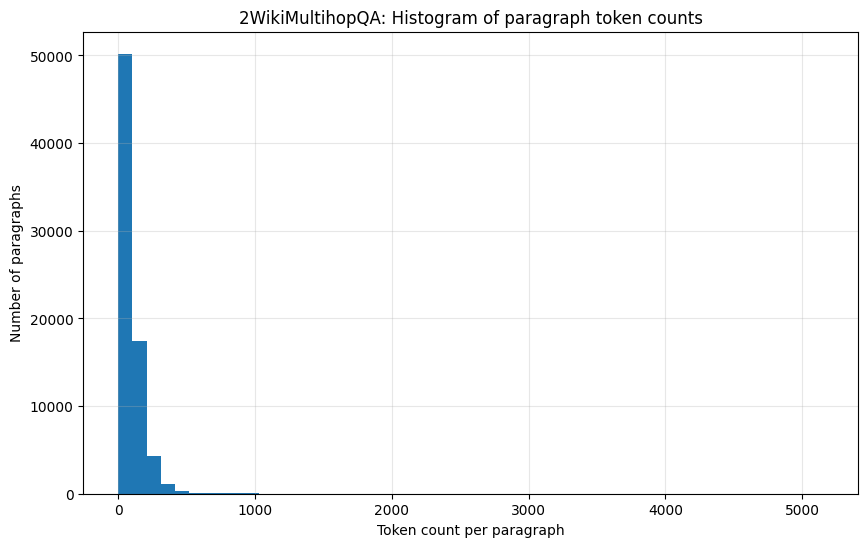

In [13]:
# Cell 13: Plot 2Wiki token histogram
plt.figure(figsize=(10, 6))
plt.hist(paragraphs_2wiki_df["token_count"], bins=50)

plt.xlabel("Token count per paragraph")
plt.ylabel("Number of paragraphs")
plt.title("2WikiMultihopQA: Histogram of paragraph token counts")
plt.grid(True, alpha=0.3)

plt.show()

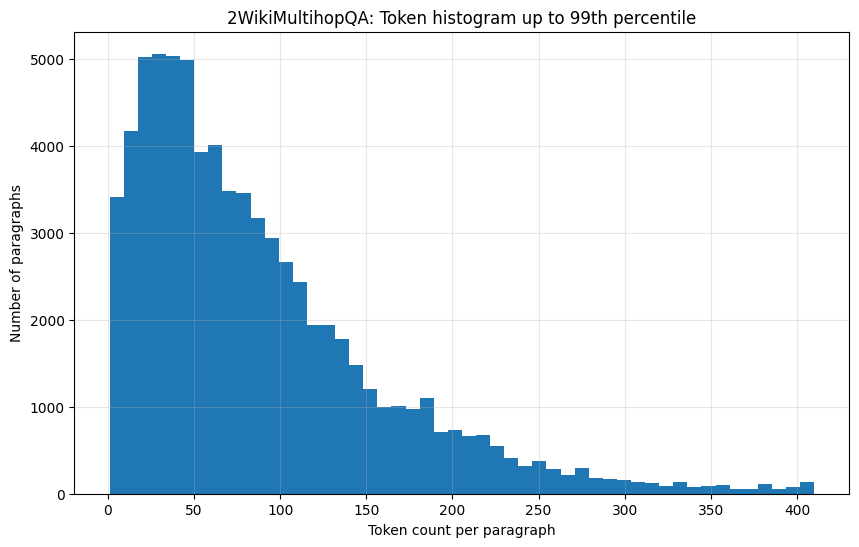

99th percentile token limit: 410
Paragraphs used in filtered histogram: 73150


In [14]:
# Cell 14: Plot 2Wiki token histogram without extreme outliers
upper_limit_2wiki = paragraphs_2wiki_df["token_count"].quantile(0.99)

filtered_2wiki_df = paragraphs_2wiki_df[
    paragraphs_2wiki_df["token_count"] <= upper_limit_2wiki
]

plt.figure(figsize=(10, 6))
plt.hist(filtered_2wiki_df["token_count"], bins=50)

plt.xlabel("Token count per paragraph")
plt.ylabel("Number of paragraphs")
plt.title("2WikiMultihopQA: Token histogram up to 99th percentile")
plt.grid(True, alpha=0.3)

plt.show()

print("99th percentile token limit:", int(upper_limit_2wiki))
print("Paragraphs used in filtered histogram:", len(filtered_2wiki_df))

In [15]:
# Cell 15: Compare HotpotQA and 2Wiki paragraph token statistics
comparison_rows = [
    {
        "dataset": "HotpotQA 2017Wiki",
        "questions": len(data),
        "paragraphs": len(paragraphs_df),
        "total_tokens": int(paragraphs_df["token_count"].sum()),
        "mean_tokens": round(paragraphs_df["token_count"].mean(), 2),
        "median_tokens": round(paragraphs_df["token_count"].median(), 2),
        "max_tokens": int(paragraphs_df["token_count"].max()),
        "p95_tokens": round(paragraphs_df["token_count"].quantile(0.95), 2),
        "p99_tokens": round(paragraphs_df["token_count"].quantile(0.99), 2),
    },
    {
        "dataset": "2WikiMultihopQA 2020Wiki",
        "questions": len(data_2wiki),
        "paragraphs": len(paragraphs_2wiki_df),
        "total_tokens": int(paragraphs_2wiki_df["token_count"].sum()),
        "mean_tokens": round(paragraphs_2wiki_df["token_count"].mean(), 2),
        "median_tokens": round(paragraphs_2wiki_df["token_count"].median(), 2),
        "max_tokens": int(paragraphs_2wiki_df["token_count"].max()),
        "p95_tokens": round(paragraphs_2wiki_df["token_count"].quantile(0.95), 2),
        "p99_tokens": round(paragraphs_2wiki_df["token_count"].quantile(0.99), 2),
    }
]

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,dataset,questions,paragraphs,total_tokens,mean_tokens,median_tokens,max_tokens,p95_tokens,p99_tokens
0,HotpotQA 2017Wiki,1000,129185,13569149,105.04,90.0,1895,253.0,366.0
1,2WikiMultihopQA 2020Wiki,1000,73878,6926066,93.75,69.0,5151,245.0,410.0
